# White-Black Within-Inflation Trend Tests

This notebook tests whether the within part of Half Edge can help explain why the White-Black Half Edge trend diverges from Moran over time.

The working hypothesis is:

1. Half Edge with `lambda=1` contains same-tract products; Half Edge with `lambda=0` removes them.
2. Same-tract `within_xx` products grow mechanically with Black-count variance across tracts.
3. If Black-count heterogeneity and within-product share fall over time, the lambda-sensitive part of Half Edge should fall with them, while Moran can remain flatter or rise because it is centered and standardized.

The metric columns come directly from `white_black.csv`. The graph JSONs are loaded only to compute the decomposition diagnostics.

In [2]:
from pathlib import Path
import json
import re

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:.4f}".format

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "outputs").exists():
    project_root = project_root.parent

csv_path = project_root / "outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv"
if not csv_path.exists():
    raise FileNotFoundError(csv_path)

csv_path

PosixPath('/Users/maria/Documents/capy-bara/outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv')

In [3]:
metrics = pd.read_csv(csv_path)

required_columns = [
    "filename",
    "x_col",
    "y_col",
    "half_edge_lam_0_angle_1",
    "half_edge_lam_1_angle_1",
    "moran",
    "total_nodes",
    "total_edges",
]
missing_columns = sorted(set(required_columns) - set(metrics.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

if set(metrics["x_col"].dropna().unique()) != {"BLACK"}:
    raise ValueError("Expected x_col to be BLACK throughout.")
if set(metrics["y_col"].dropna().unique()) != {"WHITE"}:
    raise ValueError("Expected y_col to be WHITE throughout.")

metrics["year"] = metrics["filename"].str.extract(r"/(\d{4})/")[0].astype(int)
metrics["cbsa"] = metrics["filename"].str.extract(r"cbsa_(\d+)_")[0]
metrics["area_key"] = metrics["year"].astype(str) + "_" + metrics["cbsa"].astype(str)
metrics["graph_path"] = metrics["filename"].map(lambda filename: project_root / filename)

missing_graphs = metrics.loc[~metrics["graph_path"].map(Path.exists), "graph_path"].tolist()
if missing_graphs:
    raise FileNotFoundError(f"Missing graph JSONs, starting with: {missing_graphs[:5]}")

year_order = sorted(metrics["year"].unique())
metrics["year_label"] = pd.Categorical(
    metrics["year"].astype(str),
    categories=[str(year) for year in year_order],
    ordered=True,
)

print(f"Loaded {len(metrics):,} White-Black metric rows")
display(metrics.groupby("year").size().rename("n_areas").to_frame())

Loaded 1,939 White-Black metric rows


,n_areas
year,
1980,379
1990,384
2000,392
2010,392
2020,392


## Decomposition Diagnostics

For each graph:

`within_xx = sum_i BLACK_i^2`

`within_xy = sum_i BLACK_i * WHITE_i`

`within_yy = sum_i WHITE_i^2`

The between terms use adjacent tracts only. For an undirected edge `i--j`, the notebook counts the directed products in the same convention as `angle_1`:

`between_xx += BLACK_i * BLACK_j + BLACK_j * BLACK_i`

`between_xy += BLACK_i * WHITE_j + BLACK_j * WHITE_i`

`between_yy += WHITE_i * WHITE_j + WHITE_j * WHITE_i`

The Black-count CV uses population standard deviation (`ddof=0`) so that the identity below is exact:

`within_xx_inflation = within_xx / n / mean(BLACK)^2 = 1 + black_count_cv^2`

In [4]:
decomposition_records = []

for row_number, row in enumerate(metrics.itertuples(index=False), start=1):
    with row.graph_path.open() as graph_file:
        graph_data = json.load(graph_file)

    nodes = graph_data["nodes"]
    adjacency = graph_data["adjacency"]
    node_by_id = {node["id"]: node for node in nodes}

    black_counts = np.array([float(node.get("BLACK", 0) or 0) for node in nodes], dtype=float)
    white_counts = np.array([float(node.get("WHITE", 0) or 0) for node in nodes], dtype=float)
    total_counts = black_counts + white_counts

    black_count_mean = black_counts.mean()
    black_count_var = black_counts.var(ddof=0)
    black_count_cv = (
        black_counts.std(ddof=0) / black_count_mean if black_count_mean > 0 else np.nan
    )
    total_pop_mean = total_counts.mean()
    total_pop_cv = (
        total_counts.std(ddof=0) / total_pop_mean if total_pop_mean > 0 else np.nan
    )

    within_xx = float(np.sum(black_counts * black_counts))
    within_xy = float(np.sum(black_counts * white_counts))
    within_yy = float(np.sum(white_counts * white_counts))

    between_xx = 0.0
    between_xy = 0.0
    between_yy = 0.0
    edge_keys = set()

    for source_node, neighbors in zip(nodes, adjacency):
        source_id = source_node["id"]
        for neighbor in neighbors:
            target_id = neighbor["id"]
            edge_key = tuple(sorted((source_id, target_id)))
            if source_id == target_id or edge_key in edge_keys:
                continue
            edge_keys.add(edge_key)

            target_node = node_by_id[target_id]
            x_source = float(source_node.get("BLACK", 0) or 0)
            y_source = float(source_node.get("WHITE", 0) or 0)
            x_target = float(target_node.get("BLACK", 0) or 0)
            y_target = float(target_node.get("WHITE", 0) or 0)

            between_xx += x_source * x_target + x_target * x_source
            between_xy += x_source * y_target + x_target * y_source
            between_yy += y_source * y_target + y_target * y_source

    n_nodes = len(nodes)
    within_total = within_xx + (2 * within_xy) + within_yy
    between_total = between_xx + (2 * between_xy) + between_yy
    within_xx_per_node = within_xx / n_nodes if n_nodes else np.nan
    within_xx_inflation = (
        within_xx_per_node / (black_count_mean**2) if black_count_mean > 0 else np.nan
    )

    decomposition_records.append(
        {
            "filename": row.filename,
            "area_key": row.area_key,
            "year": row.year,
            "cbsa": row.cbsa,
            "edge_count_from_json": len(edge_keys),
            "black_count_mean": black_count_mean,
            "black_count_var": black_count_var,
            "black_count_cv": black_count_cv,
            "total_pop_cv": total_pop_cv,
            "within_xx": within_xx,
            "within_xy": within_xy,
            "within_yy": within_yy,
            "between_xx": between_xx,
            "between_xy": between_xy,
            "between_yy": between_yy,
            "within_total": within_total,
            "between_total": between_total,
            "within_total_share": within_total / (within_total + between_total),
            "within_xx_share": within_xx / (within_xx + between_xx),
            "within_xx_per_node": within_xx_per_node,
            "within_xx_inflation": within_xx_inflation,
            "within_xx_inflation_identity": 1 + black_count_cv**2,
        }
    )

    if row_number % 500 == 0:
        print(f"Loaded {row_number:,} graph JSONs...")

decomposition = pd.DataFrame(decomposition_records)
print(f"Computed decomposition diagnostics for {len(decomposition):,} graphs")

Loaded 500 graph JSONs...
Loaded 1,000 graph JSONs...
Loaded 1,500 graph JSONs...
Computed decomposition diagnostics for 1,939 graphs


In [5]:
analysis = metrics.merge(
    decomposition,
    on=["filename", "area_key", "year", "cbsa"],
    how="inner",
    validate="one_to_one",
)

if len(analysis) != len(metrics):
    raise ValueError(f"Expected {len(metrics)} merged rows, got {len(analysis)}")

edge_mismatch = analysis["edge_count_from_json"] - analysis["total_edges"]
if not (edge_mismatch == 0).all():
    raise ValueError(edge_mismatch.describe())

identity_error = (
    analysis["within_xx_inflation"] - analysis["within_xx_inflation_identity"]
).abs().max()
if identity_error > 1e-8:
    raise ValueError(f"within_xx inflation identity failed: max error {identity_error}")

analysis["he_lambda_gap"] = (
    analysis["half_edge_lam_1_angle_1"] - analysis["half_edge_lam_0_angle_1"]
)
analysis["he_lambda_ratio"] = (
    analysis["half_edge_lam_1_angle_1"] / analysis["half_edge_lam_0_angle_1"]
)
analysis["he_lambda_pct_change"] = analysis["he_lambda_ratio"] - 1

print(f"Max identity error: {identity_error:.3e}")
display(
    analysis[
        [
            "year",
            "cbsa",
            "half_edge_lam_0_angle_1",
            "half_edge_lam_1_angle_1",
            "moran",
            "black_count_cv",
            "within_total_share",
            "within_xx_inflation",
            "he_lambda_gap",
            "he_lambda_ratio",
        ]
    ].head()
)

Max identity error: 7.105e-15


,year,cbsa,half_edge_lam_0_angle_1,half_edge_lam_1_angle_1,moran,black_count_cv,within_total_share,within_xx_inflation,he_lambda_gap,he_lambda_ratio
0,2020,42700,0.5141,0.5240,0.2107,0.9812,0.1909,1.9628,0.0099,1.0192
1,2020,23900,0.5027,0.5034,0.4635,0.9455,0.1892,1.8940,0.0007,1.0014
2,2020,22520,0.5215,0.5278,0.2132,0.8596,0.1780,1.7389,0.0062,1.0120
3,2020,14540,0.5293,0.5339,0.3083,1.2225,0.1797,2.4945,0.0046,1.0086
4,2020,43300,0.5125,0.5164,0.4209,0.8903,0.1805,1.7927,0.0039,1.0076


## Metric Trends

This reproduces the high-level pattern for the metric columns: yearly means for edge-only Half Edge, default Half Edge, and Moran.

,year,"Half Edge, lambda=0","Half Edge, lambda=1",Moran
0,1980,0.5518,0.5639,0.2738
1,1990,0.5494,0.5582,0.3671
2,2000,0.5477,0.5555,0.3959
3,2010,0.5457,0.5525,0.4320
4,2020,0.5460,0.5523,0.4701


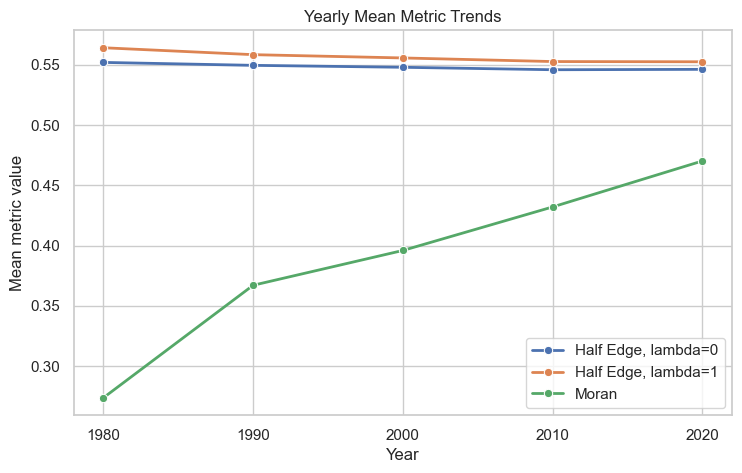

In [6]:
metric_labels = {
    "half_edge_lam_0_angle_1": "Half Edge, lambda=0",
    "half_edge_lam_1_angle_1": "Half Edge, lambda=1",
    "moran": "Moran",
}

yearly_metric_means = (
    analysis.groupby("year", as_index=False)[list(metric_labels)]
    .mean()
)
metric_plot_data = yearly_metric_means.melt(
    id_vars="year",
    var_name="metric",
    value_name="mean_value",
)
metric_plot_data["metric"] = metric_plot_data["metric"].map(metric_labels)

display(yearly_metric_means.rename(columns=metric_labels))

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=metric_plot_data,
    x="year",
    y="mean_value",
    hue="metric",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Yearly Mean Metric Trends")
ax.set_xlabel("Year")
ax.set_ylabel("Mean metric value")
ax.set_xticks(year_order)
ax.legend(title=None)
plt.show()

## Black Count CV Trend

This is the direct heterogeneity term behind `within_xx` inflation. It uses population CV so it matches the identity exactly.

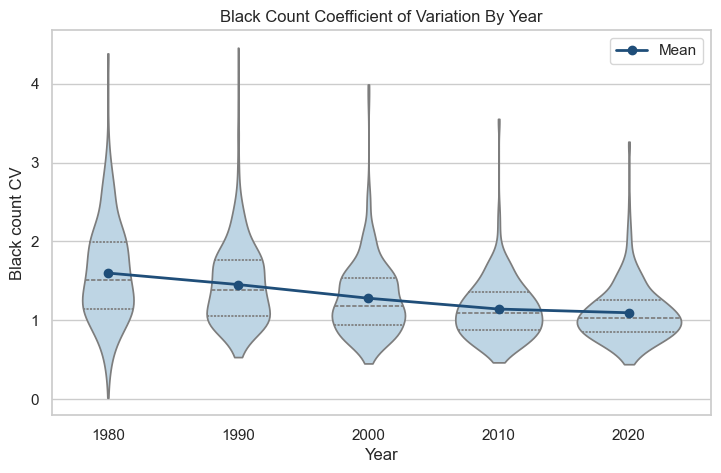

,mean_black_count_cv
year,
1980,1.5982
1990,1.4518
2000,1.2784
2010,1.1410
2020,1.0940


In [8]:
black_cv_means = analysis.groupby("year")["black_count_cv"].mean().reindex(year_order)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.violinplot(
    data=analysis,
    x="year_label",
    y="black_count_cv",
    inner="quartile",
    cut=0,
    color="#B8D7EA",
    ax=ax,
)
ax.plot(
    range(len(year_order)),
    black_cv_means.values,
    marker="o",
    color="#1F4E79",
    linewidth=2,
    label="Mean",
)
ax.set_title("Black Count Coefficient of Variation By Year")
ax.set_xlabel("Year")
ax.set_ylabel("Black count CV")
ax.legend()
plt.show()

display(black_cv_means.rename("mean_black_count_cv").to_frame())

## Within Share Trend

`within_total_share` is the share of total product mass coming from same-tract products:

`within_total / (within_total + between_total)`

where:

`within_total = within_xx + 2 * within_xy + within_yy`

`between_total = between_xx + 2 * between_xy + between_yy`

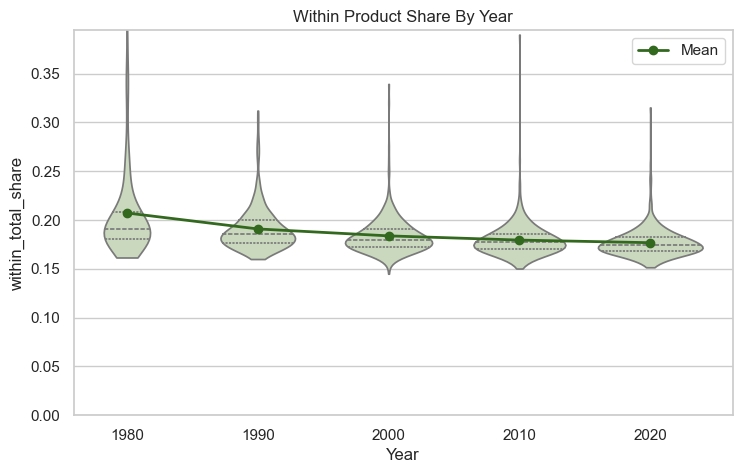

,mean_within_total_share
year,
1980,0.2072
1990,0.1908
2000,0.1837
2010,0.1794
2020,0.1767


In [9]:
within_share_means = analysis.groupby("year")["within_total_share"].mean().reindex(year_order)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.violinplot(
    data=analysis,
    x="year_label",
    y="within_total_share",
    inner="quartile",
    cut=0,
    color="#C9DDBA",
    ax=ax,
)
ax.plot(
    range(len(year_order)),
    within_share_means.values,
    marker="o",
    color="#33691E",
    linewidth=2,
    label="Mean",
)
ax.set_title("Within Product Share By Year")
ax.set_xlabel("Year")
ax.set_ylabel("within_total_share")
ax.set_ylim(0, min(1, analysis["within_total_share"].quantile(0.995) * 1.1))
ax.legend()
plt.show()

display(within_share_means.rename("mean_within_total_share").to_frame())

## `within_xx` Inflation Trend

`within_xx_inflation` isolates the mechanical second-moment effect for the Black-Black same-tract product.


`within_xx = sum_i b_i^2`

`black_count_cv^2 = Var(B) / mean(B)^2`

`within_xx_inflation = 1 + black_count_cv^2`

1 is the equal-count baseline. If every tract had exactly the same Black count, then Var(B) = 0, CV = 0, and: `within_xx_inflation = 1`

Values above `1` are the contribution of tract-level Black-count variance.
But if Black counts are uneven across tracts, high-count tracts matter disproportionately because within_xx uses squares. Example:
```
counts: 10, 10
mean = 10
mean(square) = 100
inflation = 100 / 100 = 1
```

versus:
```
counts: 0, 20
mean = 10
mean(square) = 200
inflation = 200 / 100 = 2
```

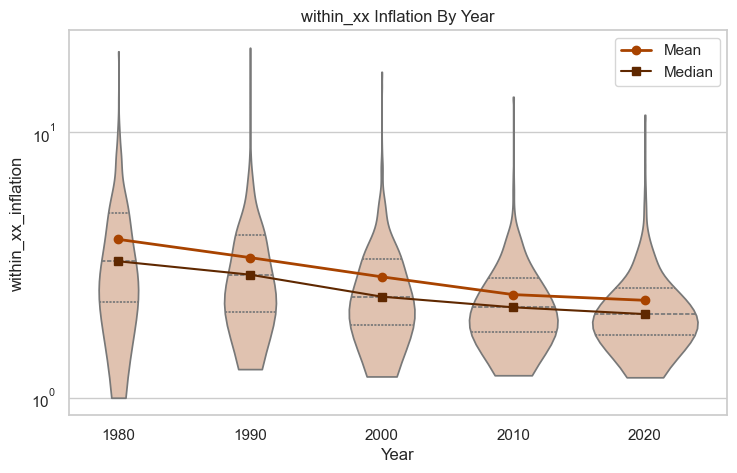

,mean_within_xx_inflation,median_within_xx_inflation
year,,
1980,3.9548,3.2698
1990,3.3761,2.9110
2000,2.8577,2.4053
2010,2.4488,2.1927
2020,2.3303,2.0677


In [10]:
inflation_means = analysis.groupby("year")["within_xx_inflation"].mean().reindex(year_order)
inflation_medians = analysis.groupby("year")["within_xx_inflation"].median().reindex(year_order)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.violinplot(
    data=analysis,
    x="year_label",
    y="within_xx_inflation",
    inner="quartile",
    cut=0,
    color="#E8C0A8",
    ax=ax,
)
ax.plot(
    range(len(year_order)),
    inflation_means.values,
    marker="o",
    color="#A84300",
    linewidth=2,
    label="Mean",
)
ax.plot(
    range(len(year_order)),
    inflation_medians.values,
    marker="s",
    color="#5F2800",
    linewidth=1.5,
    label="Median",
)
ax.set_title("within_xx Inflation By Year")
ax.set_xlabel("Year")
ax.set_ylabel("within_xx_inflation")
ax.set_yscale("log")
ax.legend()
plt.show()

display(
    pd.DataFrame(
        {
            "mean_within_xx_inflation": inflation_means,
            "median_within_xx_inflation": inflation_medians,
        }
    )
)

## Is The Half Edge Decline Concentrated In The Lambda-Sensitive Part?

The lambda-sensitive part is measured two ways:

`he_lambda_gap = HalfEdge(lambda=1) - HalfEdge(lambda=0)`

`he_lambda_ratio = HalfEdge(lambda=1) / HalfEdge(lambda=0)`

If the within term is part of the decline, these should fall over time, and their fall should line up with lower Black CV / lower `within_xx` inflation.

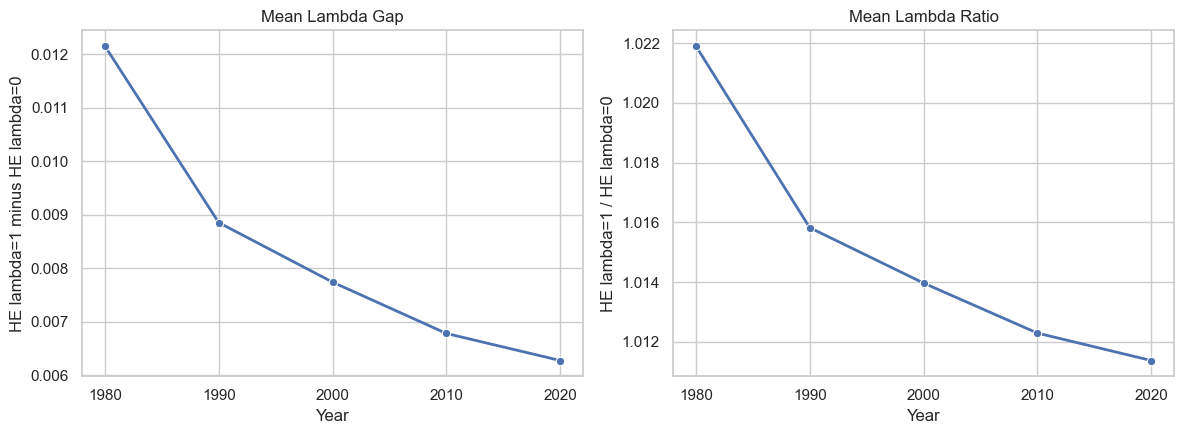

,year,half_edge_lam_0,half_edge_lam_1,moran,he_lambda_gap,he_lambda_ratio,black_count_cv,within_total_share,within_xx_inflation
0,1980,0.5518,0.5639,0.2738,0.0122,1.0219,1.5982,0.2072,3.9548
1,1990,0.5494,0.5582,0.3671,0.0089,1.0158,1.4518,0.1908,3.3761
2,2000,0.5477,0.5555,0.3959,0.0077,1.0140,1.2784,0.1837,2.8577
3,2010,0.5457,0.5525,0.4320,0.0068,1.0123,1.1410,0.1794,2.4488
4,2020,0.5460,0.5523,0.4701,0.0063,1.0114,1.0940,0.1767,2.3303


,component,value
0,Half Edge lambda=1 change,-0.0116
1,Half Edge lambda=0 change,-0.0058
2,Lambda gap change,-0.0059
3,Lambda gap share of lambda=1 change,0.5055


In [11]:
yearly_lambda = (
    analysis.groupby("year", as_index=False)
    .agg(
        half_edge_lam_0=("half_edge_lam_0_angle_1", "mean"),
        half_edge_lam_1=("half_edge_lam_1_angle_1", "mean"),
        moran=("moran", "mean"),
        he_lambda_gap=("he_lambda_gap", "mean"),
        he_lambda_ratio=("he_lambda_ratio", "mean"),
        black_count_cv=("black_count_cv", "mean"),
        within_total_share=("within_total_share", "mean"),
        within_xx_inflation=("within_xx_inflation", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(
    data=yearly_lambda,
    x="year",
    y="he_lambda_gap",
    marker="o",
    linewidth=2,
    ax=axes[0],
)
axes[0].set_title("Mean Lambda Gap")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("HE lambda=1 minus HE lambda=0")
axes[0].set_xticks(year_order)

sns.lineplot(
    data=yearly_lambda,
    x="year",
    y="he_lambda_ratio",
    marker="o",
    linewidth=2,
    ax=axes[1],
)
axes[1].set_title("Mean Lambda Ratio")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("HE lambda=1 / HE lambda=0")
axes[1].set_xticks(year_order)
plt.tight_layout()
plt.show()

display(yearly_lambda)

first_year = min(year_order)
last_year = max(year_order)
first = yearly_lambda.loc[yearly_lambda["year"] == first_year].iloc[0]
last = yearly_lambda.loc[yearly_lambda["year"] == last_year].iloc[0]
he1_change = last["half_edge_lam_1"] - first["half_edge_lam_1"]
he0_change = last["half_edge_lam_0"] - first["half_edge_lam_0"]
gap_change = last["he_lambda_gap"] - first["he_lambda_gap"]

decline_decomposition = pd.DataFrame(
    {
        "component": [
            "Half Edge lambda=1 change",
            "Half Edge lambda=0 change",
            "Lambda gap change",
            "Lambda gap share of lambda=1 change",
        ],
        "value": [
            he1_change,
            he0_change,
            gap_change,
            gap_change / he1_change if he1_change != 0 else np.nan,
        ],
    }
)
display(decline_decomposition)

## Do The Pieces Move Together?

This plot puts the yearly means on a common z-score scale. With only five years, this is descriptive rather than a formal causal test. The question is whether the lambda-sensitive Half Edge part declines in the same direction as Black-count heterogeneity and `within_xx` inflation.

For each moving variable, take its five yearly means, subtracts that quantity’s own average, and divides by that quantity’s own standard deviation:
`(value - mean_across_years) / sd_across_years`

So 0 means “this year is at that quantity’s 1980-2020 average,” +1 means “one standard deviation above its own average,” and -1 means “one standard deviation below.” = Rescaling so variables with different units can be compared visually.

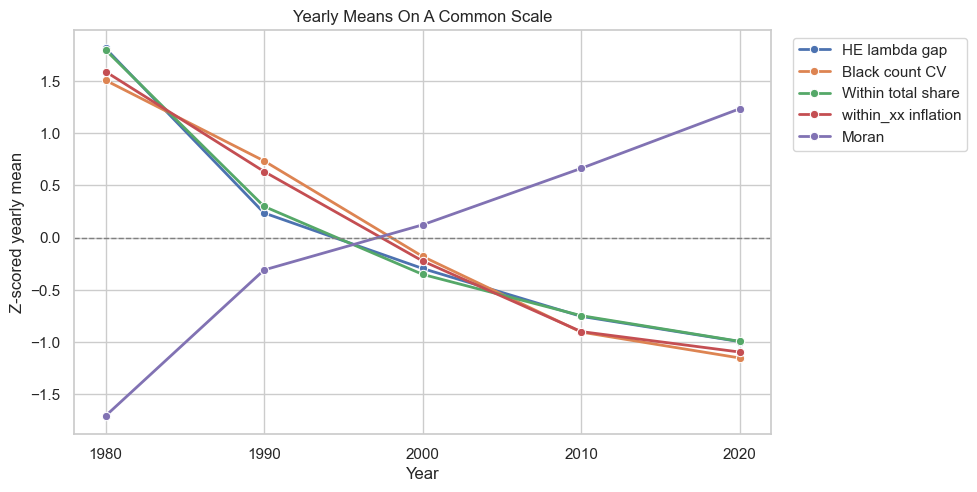

,quantity,mean_1980,mean_2020,change,pct_change_from_first_year
0,HE lambda gap,0.0122,0.0063,-0.0059,-0.4838
1,Black count CV,1.5982,1.0940,-0.5042,-0.3155
2,Within total share,0.2072,0.1767,-0.0304,-0.1469
3,within_xx inflation,3.9548,2.3303,-1.6245,-0.4108
4,Moran,0.2738,0.4701,0.1963,0.7168


,he_lambda_gap,he_lambda_ratio,black_count_cv,within_total_share,within_xx_inflation,moran
he_lambda_gap,1.0000,1.0000,0.9600,0.9990,0.9760,-0.9890
he_lambda_ratio,1.0000,1.0000,0.9550,0.9990,0.9720,-0.9880
black_count_cv,0.9600,0.9550,1.0000,0.9650,0.9980,-0.9710
within_total_share,0.9990,0.9990,0.9650,1.0000,0.9790,-0.9870
within_xx_inflation,0.9760,0.9720,0.9980,0.9790,1.0000,-0.9800
moran,-0.9890,-0.9880,-0.9710,-0.9870,-0.9800,1.0000


In [12]:
comparison_columns = {
    "he_lambda_gap": "HE lambda gap",
    "black_count_cv": "Black count CV",
    "within_total_share": "Within total share",
    "within_xx_inflation": "within_xx inflation",
    "moran": "Moran",
}

zscore_data = yearly_lambda[["year", *comparison_columns]].copy()
for column in comparison_columns:
    sd = zscore_data[column].std(ddof=0)
    zscore_data[column] = (zscore_data[column] - zscore_data[column].mean()) / sd

zscore_plot_data = zscore_data.melt(
    id_vars="year",
    var_name="quantity",
    value_name="z_scored_yearly_mean",
)
zscore_plot_data["quantity"] = zscore_plot_data["quantity"].map(comparison_columns)

fig, ax = plt.subplots(figsize=(9, 5.25))
sns.lineplot(
    data=zscore_plot_data,
    x="year",
    y="z_scored_yearly_mean",
    hue="quantity",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.axhline(0, color="0.5", linewidth=1, linestyle="--")
ax.set_title("Yearly Means On A Common Scale")
ax.set_xlabel("Year")
ax.set_ylabel("Z-scored yearly mean")
ax.set_xticks(year_order)
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

trend_rows = []
for column, label in comparison_columns.items():
    start_value = first[column]
    end_value = last[column]
    trend_rows.append(
        {
            "quantity": label,
            f"mean_{first_year}": start_value,
            f"mean_{last_year}": end_value,
            "change": end_value - start_value,
            "pct_change_from_first_year": (end_value - start_value) / start_value
            if start_value != 0
            else np.nan,
        }
    )
trend_check = pd.DataFrame(trend_rows)
display(trend_check)

display(
    yearly_lambda[
        [
            "he_lambda_gap",
            "he_lambda_ratio",
            "black_count_cv",
            "within_total_share",
            "within_xx_inflation",
            "moran",
        ]
    ].corr().round(3)
)

## Common-CBSA Sensitivity Check

The full yearly means use all available CBSAs in each year. This quick check repeats the same means using only CBSAs present in every year, so the trend is not driven only by areas entering or leaving the file.

In [13]:
common_cbsas = (
    analysis.groupby("cbsa")["year"]
    .nunique()
    .loc[lambda counts: counts == len(year_order)]
    .index
)
common_analysis = analysis[analysis["cbsa"].isin(common_cbsas)].copy()

selected_trend_columns = [
    "half_edge_lam_0_angle_1",
    "half_edge_lam_1_angle_1",
    "moran",
    "he_lambda_gap",
    "black_count_cv",
    "within_total_share",
    "within_xx_inflation",
]

full_panel_summary = (
    analysis.groupby("year")[selected_trend_columns]
    .mean()
    .assign(panel="all available CBSAs")
    .reset_index()
)
common_panel_summary = (
    common_analysis.groupby("year")[selected_trend_columns]
    .mean()
    .assign(panel=f"common CBSAs only (n={len(common_cbsas)})")
    .reset_index()
)
panel_summary = pd.concat([full_panel_summary, common_panel_summary], ignore_index=True)

display(panel_summary)

,year,half_edge_lam_0_angle_1,half_edge_lam_1_angle_1,moran,he_lambda_gap,black_count_cv,within_total_share,within_xx_inflation,panel
0,1980,0.5518,0.5639,0.2738,0.0122,1.5982,0.2072,3.9548,all available CBSAs
1,1990,0.5494,0.5582,0.3671,0.0089,1.4518,0.1908,3.3761,all available CBSAs
2,2000,0.5477,0.5555,0.3959,0.0077,1.2784,0.1837,2.8577,all available CBSAs
3,2010,0.5457,0.5525,0.4320,0.0068,1.1410,0.1794,2.4488,all available CBSAs
4,2020,0.5460,0.5523,0.4701,0.0063,1.0940,0.1767,2.3303,all available CBSAs
5,1980,0.5518,0.5639,0.2738,0.0122,1.5982,0.2072,3.9548,common CBSAs only (n=379)
6,1990,0.5499,0.5588,0.3700,0.0089,1.4573,0.1904,3.3916,common CBSAs only (n=379)
7,2000,0.5493,0.5569,0.4051,0.0077,1.2708,0.1826,2.8222,common CBSAs only (n=379)
8,2010,0.5471,0.5538,0.4438,0.0067,1.1402,0.1785,2.4476,common CBSAs only (n=379)
9,2020,0.5473,0.5536,0.4816,0.0062,1.0933,0.1758,2.3305,common CBSAs only (n=379)


## How To Read The Result

The within-inflation hypothesis gets support if these patterns line up:

1. `half_edge_lam_1_angle_1` falls more than `half_edge_lam_0_angle_1`.
2. `he_lambda_gap` or `he_lambda_ratio` falls over time.
3. `black_count_cv`, `within_total_share`, and `within_xx_inflation` fall over the same years.
4. Moran does not fall in the same way.

That would not prove the whole Half Edge/Moran divergence is caused by the within term. It would show that the within term plausibly contributes to the declining Half Edge trend on top of the edge-only Moran blindspot.